# 2.3 starCAT for projecting gene expression programs to all plasma cells

Author: Xuezhu Sunny Wang

## Dataset 📊

- Seurat object of all plasma cells
- Gene list of gene expression programs, from the cNMF analysis of clonal plasma cells

## Steps overview 📒

- Use starCAT to infer the usage (activity) of gene expression programs
- Plot the change between paired pre and post treatment samples

In [1]:
import sys
from cnmf import cNMF
import os
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from starcat import starCAT



In [2]:
tcat = starCAT(reference='./cNMF_withoutIG_k=13/plasma_cNMF_3_withoutIG_k=13/plasma_cNMF_3_withoutIG_k=13.starcat_spectra.k_13.dt_2_0.txt', 
               cachedir='./query_cNMF/cache')


Using user specified reference spectra file ./cNMF_withoutIG_k=13/plasma_cNMF_3_withoutIG_k=13/plasma_cNMF_3_withoutIG_k=13.starcat_spectra.k_13.dt_2_0.txt
No scores provided


In [3]:
tcat.ref

,PERM1,ISG15,TTLL10,TNFRSF18,TNFRSF4,TAS1R3,TMEM52,MMEL1,AL512413.1,MEGF6,...,AMELY,TBL1Y,AC064829.1,AC244213.1,AC004556.3,AC233755.2,AC233755.1,AC136616.3,AC136616.2,AC141272.1
GEP1,0.000000,0.605092,0.000000,0.000000,0.000000,0.112493,0.000000,0.000000,0.001787,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
GEP2,0.046746,0.426410,0.000000,0.354571,0.360851,0.623126,0.449011,0.029182,0.000000,0.054676,...,0.000000,0.000000,0.000000,0.022139,0.214174,0.000000,0.230403,0.091618,0.310233,0.481726
GEP3,0.000000,0.377933,0.006809,0.508294,0.397441,0.169179,0.006413,0.000000,0.000000,0.040408,...,0.098393,0.080297,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
GEP4,0.000000,0.002521,0.000000,1.113971,0.975821,0.000000,0.000000,0.000000,0.001403,0.022440,...,0.000000,0.000000,0.059156,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
GEP5,0.055977,0.834073,0.052521,0.239575,0.298272,0.000000,0.384284,0.009218,0.000000,0.103687,...,0.014648,0.000000,0.000000,0.925469,0.288303,0.000000,3.531507,0.000000,0.000000,0.000000
GEP6,0.003823,0.115977,0.000000,0.124212,0.261377,0.830904,0.446456,0.004871,0.045169,0.005919,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.004694,0.000000,0.000000
GEP7,0.000000,0.142833,0.000000,0.679429,0.739847,0.038123,0.000000,0.002912,0.000000,0.001585,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
GEP8,0.000000,0.000000,0.000000,0.000000,0.000000,0.272512,0.122547,0.011927,0.000000,0.001070,...,0.044460,0.210256,0.000000,0.000000,0.161448,5.954403,0.000000,0.000000,0.000000,0.007968
GEP9,0.000000,0.649994,0.000000,0.000000,0.071790,0.000000,0.000000,0.202136,0.000000,0.136788,...,0.000000,0.000000,0.000000,0.005475,0.031971,0.000000,0.000000,0.000000,0.000000,0.000000
GEP10,0.000000,0.243783,0.000000,0.056349,0.142326,0.100253,0.000000,0.000000,0.000000,0.145105,...,0.000000,0.000000,0.000000,0.000000,0.173782,0.000000,0.000000,0.000000,0.005580,0.018929


In [4]:
adata = sc.read_h5ad("counts.h5ad")

In [5]:
# Run starCAT 
usage, _ = tcat.fit_transform(adata)


/lab-share/home/Public/Sunny/miniconda3/envs/cassiopeia/lib/python3.8/site-packages/starcat/starcat.py:244: UserWarning: WARNING!: query input is not an integer count matrix as expected.
            Please provide an integer count matrix unless you are sure you know what you are doing.
  warnings.warn("""WARNING!: query input is not an integer count matrix as expected.


2000 out of 2000 genes in the reference overlap with the query


In [6]:
usage.head()

,GEP1,GEP2,GEP3,GEP4,GEP5,GEP6,GEP7,GEP8,GEP9,GEP10,GEP11,GEP12,GEP13
ALl14_AAACGAACAGTTGTTG-1,1.356822e-02,0.178538,0.198700,0.000860,2.450875e-02,0.001016,0.000903,0.006238,5.528831e-01,0.009377,8.626594e-06,2.470986e-03,0.010929
ALl14_AAACGAAGTATCGAGG-1,3.477405e-08,0.030206,0.135598,0.036761,2.182667e-08,0.011737,0.000002,0.001184,9.909277e-02,0.665929,1.886467e-02,2.888846e-07,0.000626
ALl14_AAACGCTCAAGTGCAG-1,5.078875e-05,0.069008,0.169955,0.000018,4.197900e-02,0.001011,0.000397,0.006825,5.220535e-01,0.146092,6.295720e-08,6.100504e-03,0.036511
ALl14_AAAGAACAGAGGCTGT-1,3.890765e-07,0.102221,0.109052,0.033791,3.313666e-03,0.000001,0.222891,0.017171,2.292119e-01,0.079816,1.732428e-02,2.769686e-07,0.185206
ALl14_AAAGGATAGATGCAGC-1,3.451473e-07,0.380463,0.148958,0.286097,3.077109e-03,0.172029,0.000003,0.002438,8.509454e-09,0.000453,2.327552e-10,1.298624e-05,0.006468


In [7]:
adata

AnnData object with n_obs × n_vars = 232300 × 36601
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'percent.ig', 'percent.hb', 'unintegrated_clusters', 'seurat_clusters', 'barcode', 'subtype', 'mutation', 'S.Score', 'G2M.Score', 'Phase', 'old.ident'
    var: 'vf_vst_counts_mean', 'vf_vst_counts_variance', 'vf_vst_counts_variance.expected', 'vf_vst_counts_variance.standardized', 'vf_vst_counts_variable', 'vf_vst_counts_rank', 'var.features', 'var.features.rank'
    obsm: 'X_pca', 'X_umap'

In [8]:
# Merge usages and scores with cell metadata
adata.obs = pd.merge(left=adata.obs, right=usage, how='left', left_index=True, right_index=True)


In [9]:
adata

AnnData object with n_obs × n_vars = 232300 × 36601
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'percent.ig', 'percent.hb', 'unintegrated_clusters', 'seurat_clusters', 'barcode', 'subtype', 'mutation', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'GEP1', 'GEP2', 'GEP3', 'GEP4', 'GEP5', 'GEP6', 'GEP7', 'GEP8', 'GEP9', 'GEP10', 'GEP11', 'GEP12', 'GEP13'
    var: 'vf_vst_counts_mean', 'vf_vst_counts_variance', 'vf_vst_counts_variance.expected', 'vf_vst_counts_variance.standardized', 'vf_vst_counts_variable', 'vf_vst_counts_rank', 'var.features', 'var.features.rank'
    obsm: 'X_pca', 'X_umap'

First we plot the discrete features output by starCAT

As well as continuous scores

And we can output the continuous usages of all of the cGEPs

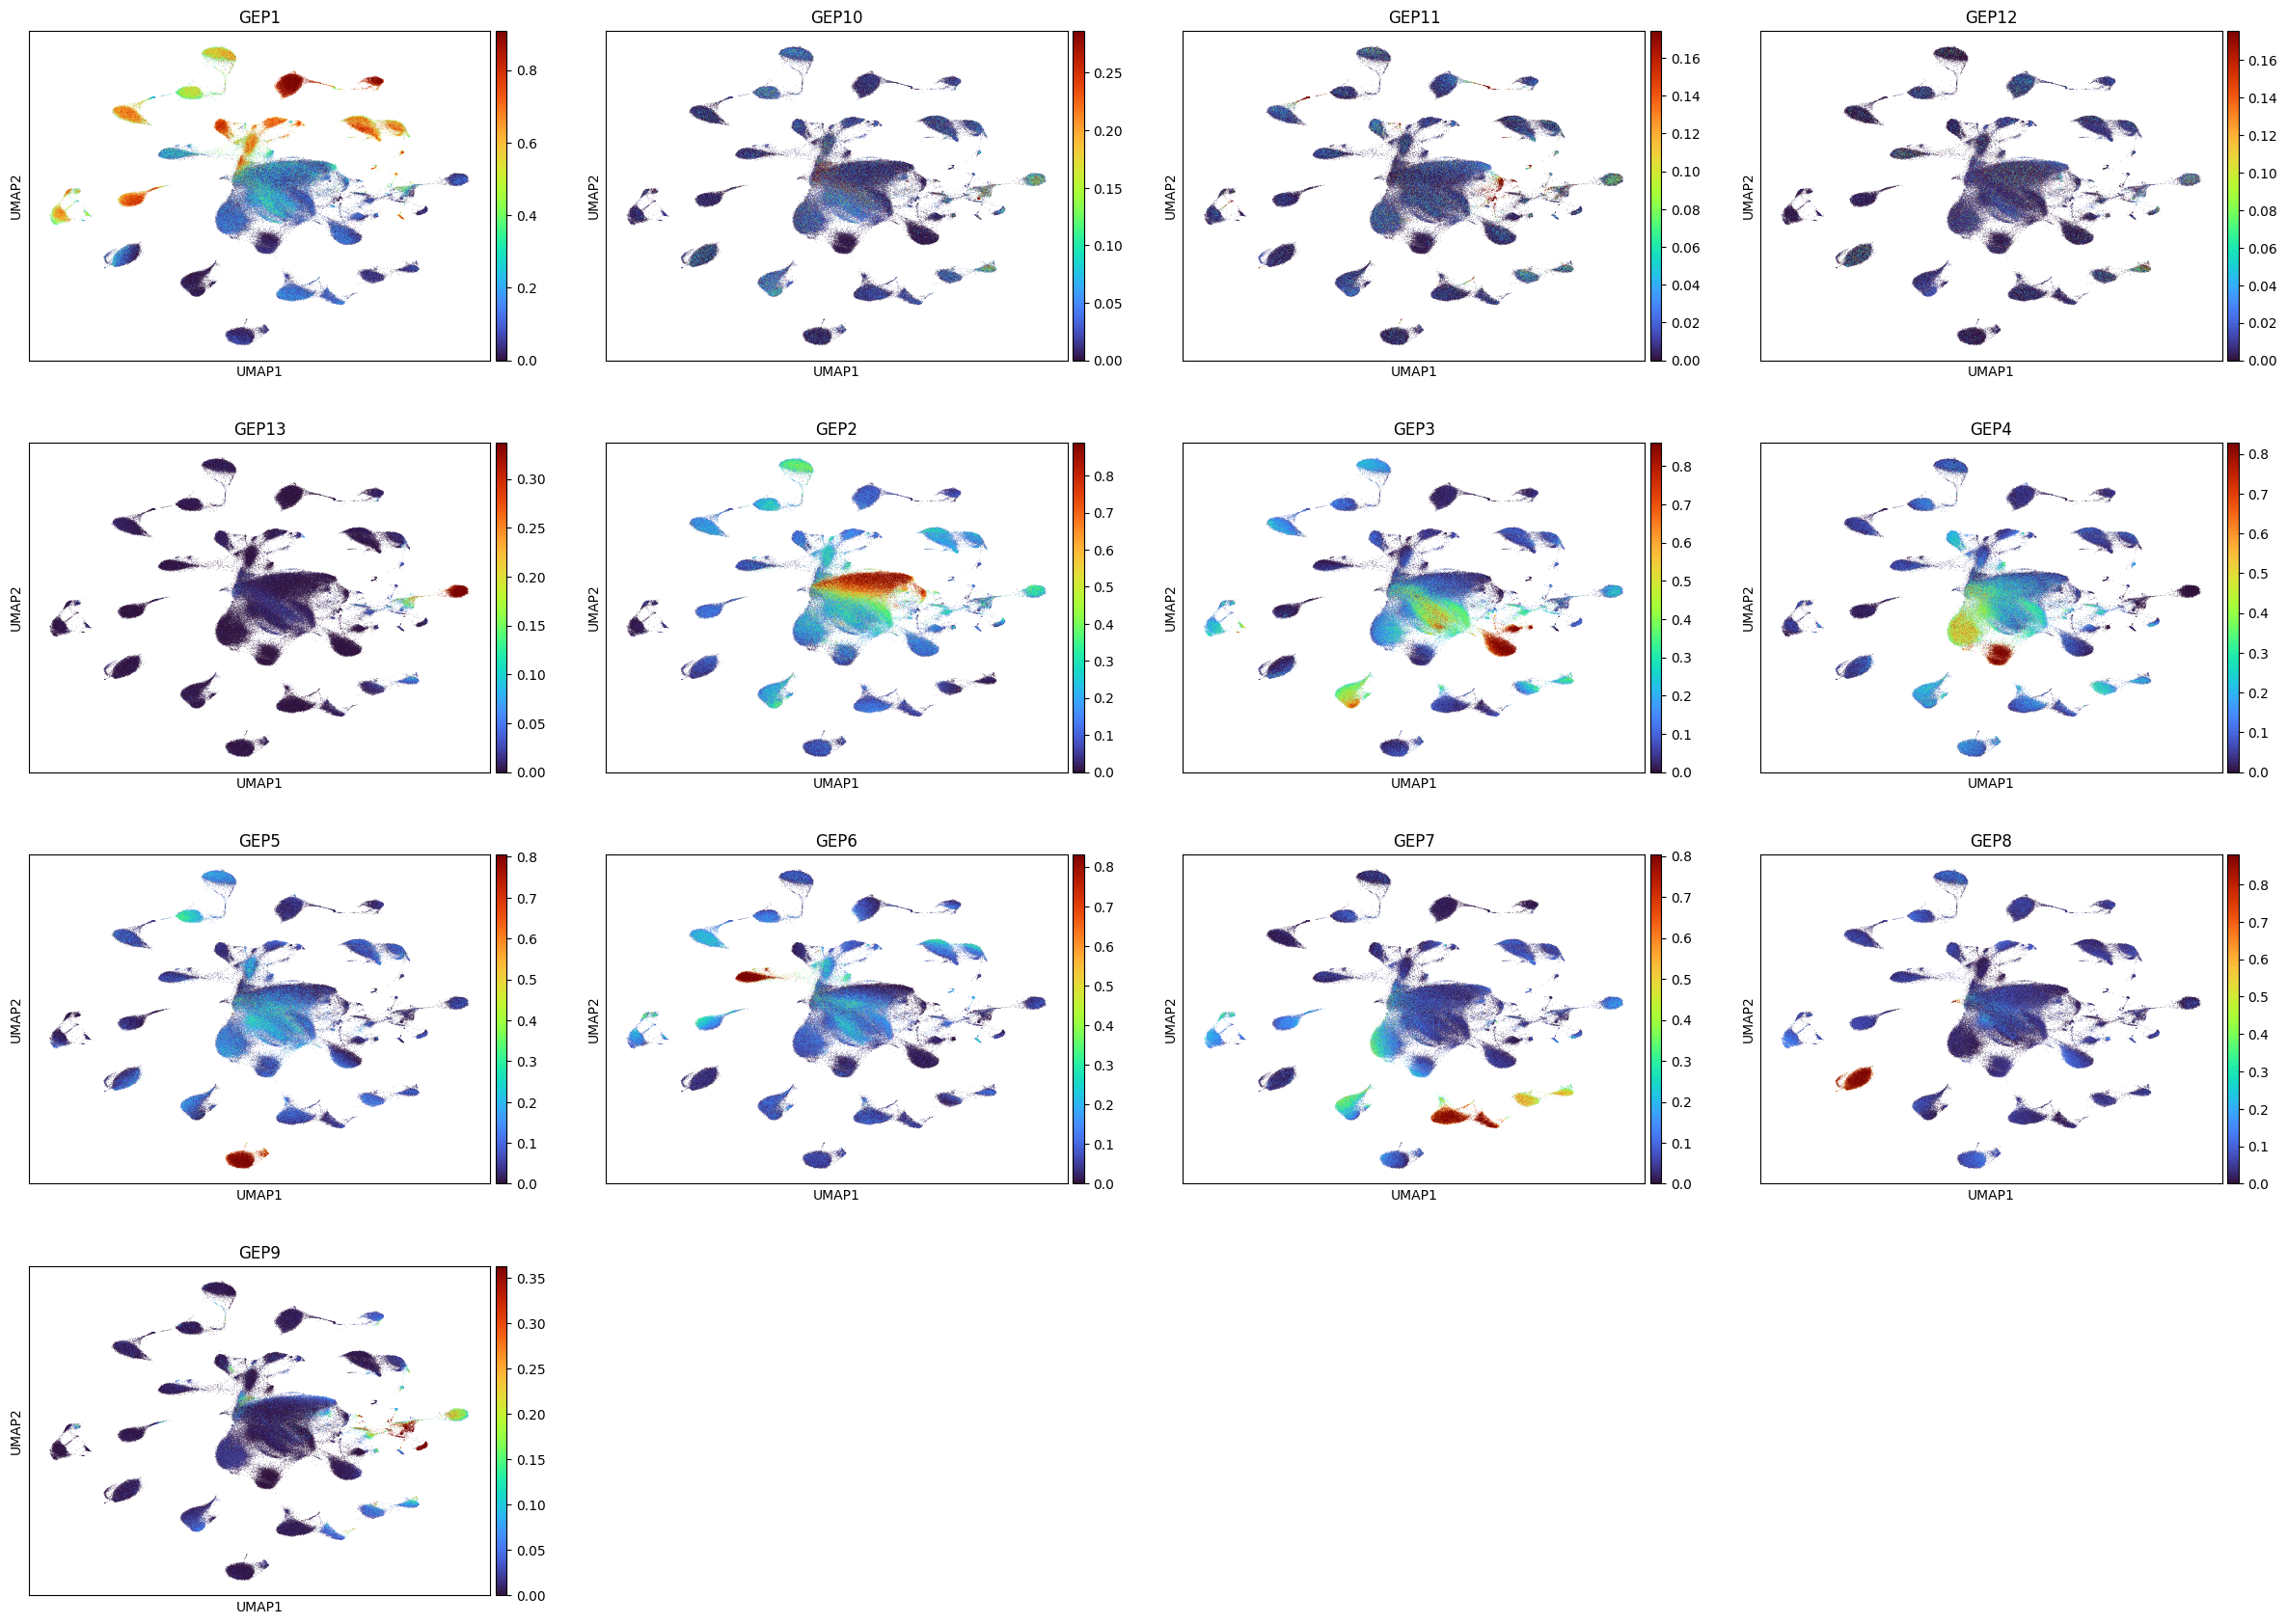

In [10]:
sc.pl.umap(adata, color=sorted(usage.columns), ncols=4, vmin=0, vmax='p99',color_map="turbo")

In [11]:
import math
import scanpy as sc
import matplotlib.pyplot as plt

# --- inputs ---
features = sorted(usage.columns)
ncols = 4
nrows = math.ceil(len(features) / ncols)

# --- make each panel more "square" by controlling inches per panel ---
panel_size = 3.2  # tune this (e.g., 2.8-4.0)
figsize = (panel_size * ncols, panel_size * nrows)

# Option A (recommended): set scanpy global figure params (works in older versions)
sc.set_figure_params(figsize=figsize)

# (Optional) tighten spacing between panels a bit
hspace = 0.35
wspace = 0.25

# --- plot (no figsize argument here) ---
sc.pl.umap(
    adata,
    color=features,
    ncols=ncols,
    vmin=0,
    vmax="p99",
    color_map="turbo",
    show=False,
    hspace=hspace,
    wspace=wspace,
)

# --- save to PDF ---
out_pdf = "umap_usage_panels.pdf"
plt.savefig(out_pdf, bbox_inches="tight")
plt.close()
print(f"Saved: {out_pdf}")


Saved: umap_usage_panels.pdf


In [12]:
import numpy as np
import pandas as pd

# --- choose the CNMF usage columns of interest ---
use_cols = ["GEP1", "GEP2", "GEP3", "GEP4", "GEP6", "GEP7", "GEP8", "GEP9","GEP11"]
present = [c for c in use_cols if c in adata.obs.columns]
if len(present) == 0:
    raise ValueError("None of the required CNMF columns are present in adata.obs")

# Subset and ensure numeric
U = adata.obs[present].apply(pd.to_numeric, errors="coerce")

# Map column name -> status number
status_map = {"GEP1":1, "GEP2":2,"GEP3":3,"GEP4":4,"GEP6":6,"GEP7":7,"GEP8":8, "GEP9":9,"GEP11":11}

# Row-wise argmax to pick the dominant component
argmax_idx = U.values.argmax(axis=1)  # returns positional index among `present`
chosen_cols = [present[i] if np.isfinite(i) else np.nan for i in argmax_idx]

# Convert chosen column names to status numbers; NaN if all four are NaN
status = []
confidence = []
for i, row in U.iterrows():
    vals = row.values.astype(float)
    if np.all(~np.isfinite(vals)):
        status.append(np.nan)
        confidence.append(np.nan)
        continue
    s = np.nansum(vals)
    m = np.nanmax(vals)
    # chosen column:
    j = np.nanargmax(vals)
    status.append(status_map[present[j]])
    # confidence = max / sum (guard zero/NaN)
    conf = (m / s) if (np.isfinite(m) and np.isfinite(s) and s > 0) else np.nan
    confidence.append(conf)

adata.obs["cnmf_status"] = pd.Series(status, index=U.index).astype("Float64")
adata.obs["cnmf_status_confidence"] = pd.Series(confidence, index=U.index).astype("Float64")

# Optional: mark low-confidence as unclassified (commented out)
# THRESH = 0.4
# mask_low = adata.obs["cnmf_status_confidence"].fillna(0) < THRESH
# adata.obs.loc[mask_low, "cnmf_status"] = pd.NA

# Make a categorical for nicer plotting (keeps numeric labels as strings)
adata.obs["cnmf_status_cat"] = (
    adata.obs["cnmf_status"]
    .astype("Int64")
    .astype(str)
    .replace({"<NA>": "NA"})
    .astype("category")
)

print(
    "Assigned cnmf_status to "
    f"{adata.obs['cnmf_status'].notna().sum()} / {adata.n_obs} cells.\n"
    "Value counts:\n",
    adata.obs["cnmf_status_cat"].value_counts(dropna=False)
)


Assigned cnmf_status to 232291 / 232300 cells.
Value counts:
 cnmf_status_cat
1     74311
2     46538
3     36734
4     29189
7     20757
8     10427
6      9414
9      3843
11     1078
NA        9
Name: count, dtype: int64


/lab-share/home/Public/Sunny/miniconda3/envs/cassiopeia/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: title={'center': 'cnmf_status_cat'}, xlabel='UMAP1', ylabel='UMAP2'>

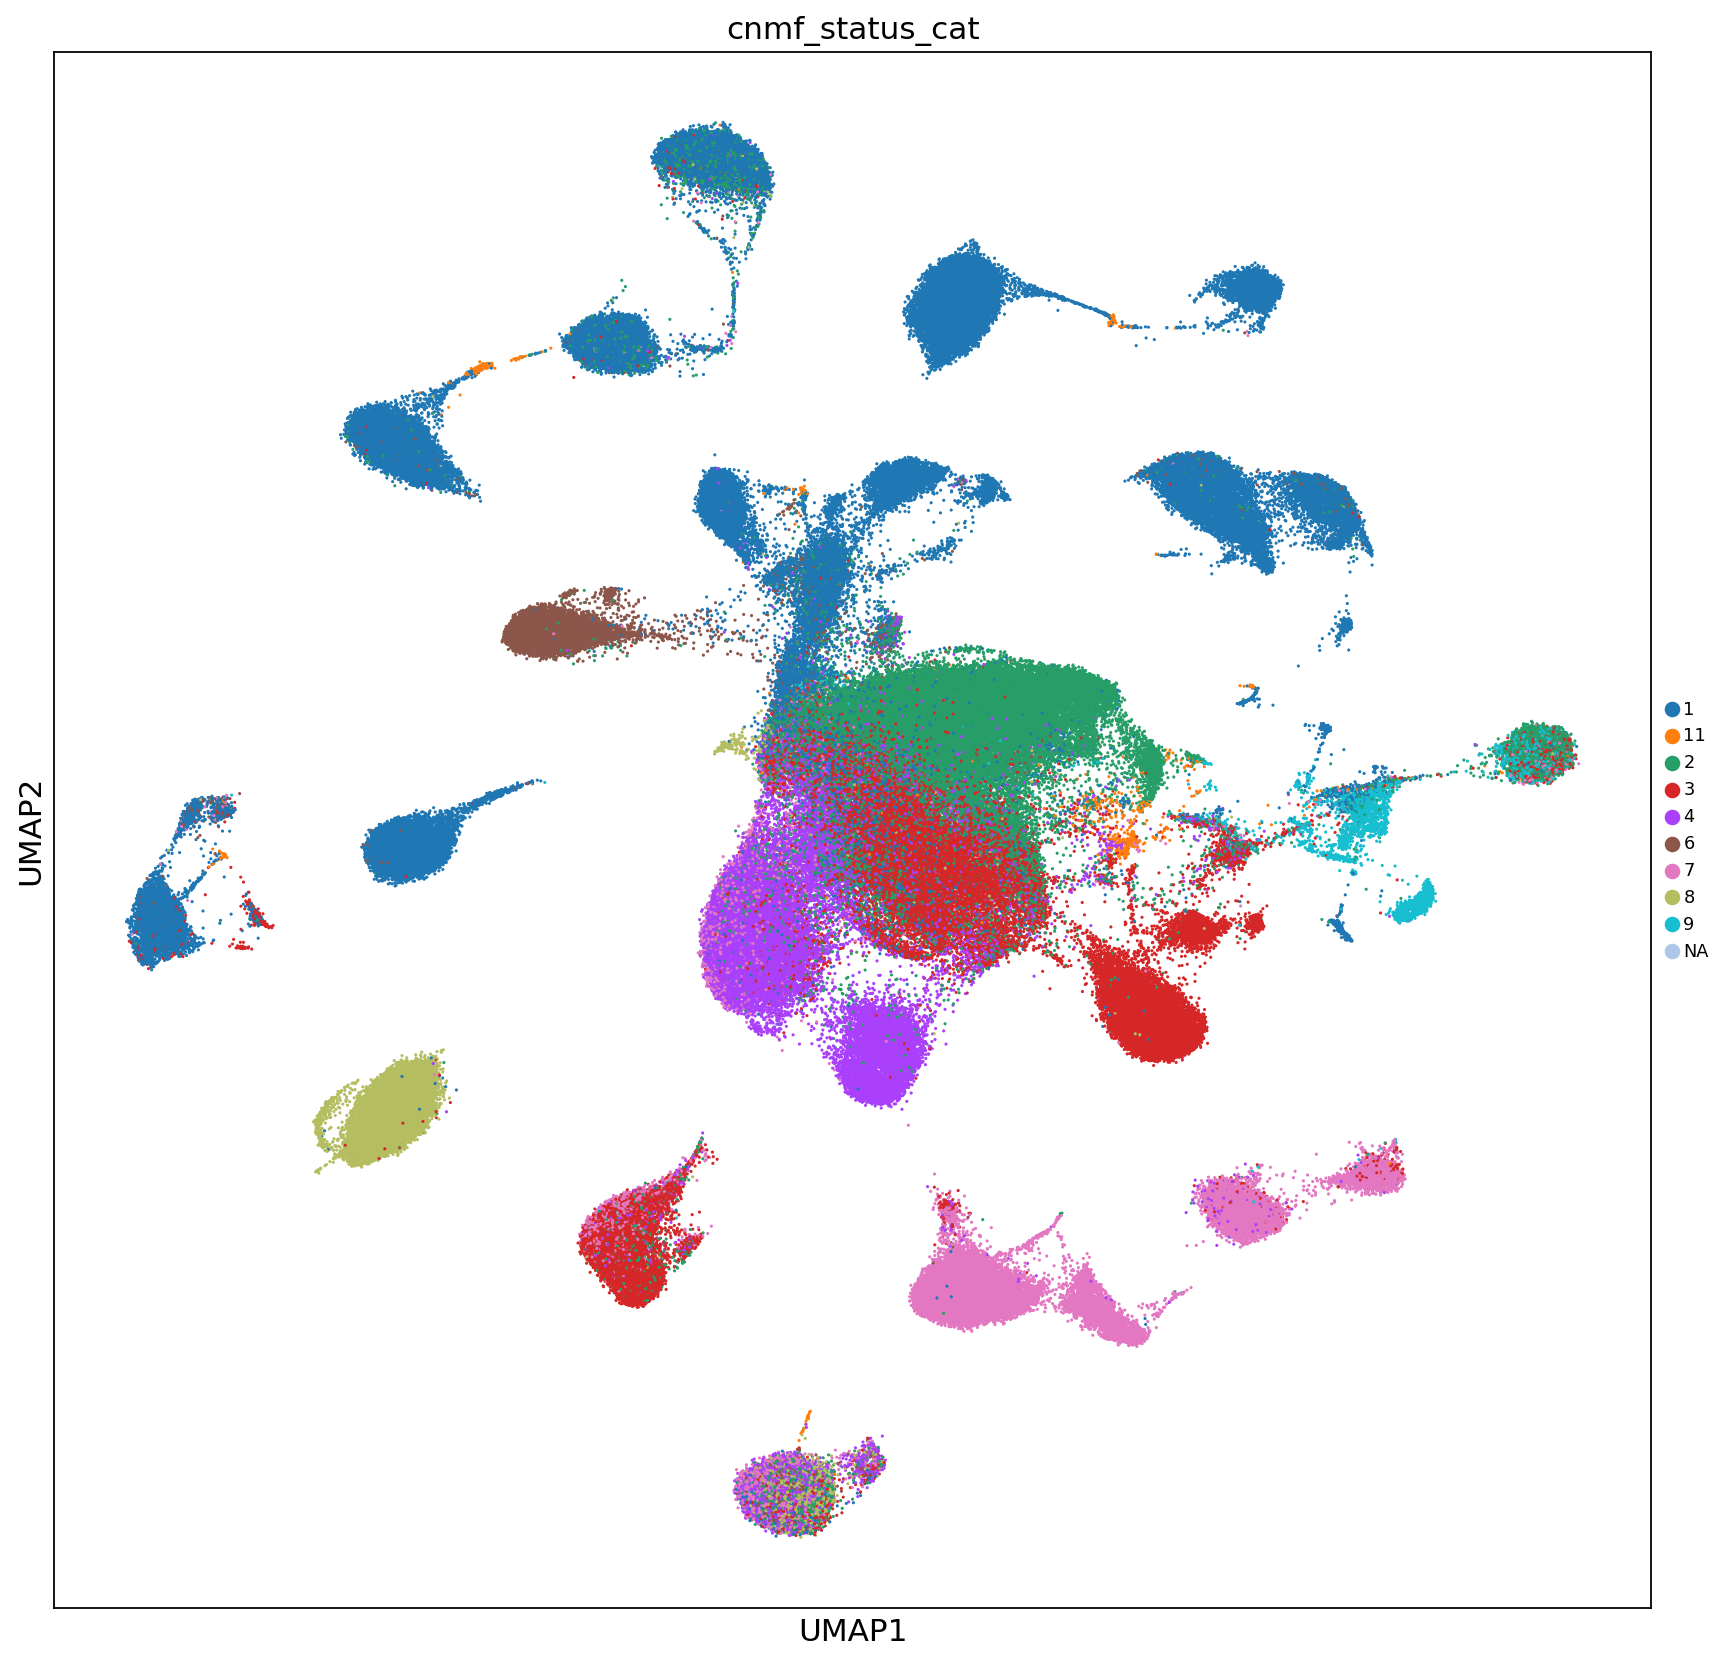

In [13]:

# --- Figure layout (2 panels side by side)
ncols = 2
nrows = 1
figsize = 5
wspace = 0.5

sc.pl.umap(
    adata,
    color=["cnmf_status_cat"],
    show=False,
    legend_loc="right margin",   # move legend outside to save space
    legend_fontsize=8,
    size=8,
    wspace=0.3,
)


In [14]:
usage_norm = adata.obs[use_cols]

In [15]:
usage_norm.to_csv("plasma_cnmf_3_usage_norm_withoutIG_k=13_allplasmacell.csv", index=True)

In [17]:
import pandas as pd

# pick the source AnnData and the column you want to transfer
src = adata
col = "cnmf_status_cat"

# export with cell barcodes (obs_names) as the key
out_csv = "cnmf_status_cat_annotation.csv"
src.obs[[col]].to_csv(out_csv, index=True)  # index=True keeps barcodes

print("Saved:", out_csv, "rows:", src.n_obs)


Saved: cnmf_status_cat_annotation.csv rows: 232300


In [26]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# ---------------------------
# 0) Inputs
# ---------------------------
gt_path   = "plasma_cnmf_3_usage_norm_withoutIG_k=13.csv"
pred_path = "plasma_cnmf_3_usage_norm_withoutIG_k=13_allplasmacell.csv"
out_pdf   = "consistency_report_k13.pdf"

# If you want Hungarian "best alignment" as an extra analysis:
RUN_HUNGARIAN = True

# Penalty strength to discourage mapping Usage_i -> GEP_j when i != j.
# Set to 0.0 for pure max-|corr| matching; increase (e.g., 0.05~0.2) to prefer i->i.
HUNGARIAN_INDEX_PENALTY = 0.10

# ---------------------------
# 1) Load
# ---------------------------
gt = pd.read_csv(gt_path)
pr = pd.read_csv(pred_path)

gt_barcode_col = gt.columns[0]
pr_barcode_col = pr.columns[0]

usage_cols = [c for c in gt.columns if re.fullmatch(r"Usage_\d+", str(c))]
gep_cols   = [c for c in pr.columns if re.fullmatch(r"GEP_?\d+", str(c))]  # supports GEP1 or GEP_1

if not usage_cols:
    raise ValueError("No columns like 'Usage_1' found in ground truth CSV.")
if not gep_cols:
    raise ValueError("No columns like 'GEP1' (or 'GEP_1') found in predicted CSV.")

def trailing_int(x: str):
    m = re.search(r"(\d+)$", str(x))
    return int(m.group(1)) if m else None

# ---------------------------
# 2) Force index-aligned pairing by suffix number
#    Usage_5 will ALWAYS pair with GEP5
# ---------------------------
usage_num_to_col = {trailing_int(c): c for c in usage_cols if trailing_int(c) is not None}
gep_num_to_col   = {trailing_int(c): c for c in gep_cols   if trailing_int(c) is not None}

common_nums = sorted(set(usage_num_to_col.keys()).intersection(set(gep_num_to_col.keys())))
if not common_nums:
    raise ValueError("No overlapping component indices between Usage_* and GEP* columns.")

usage_cols_aligned = [usage_num_to_col[i] for i in common_nums]
gep_cols_aligned   = [gep_num_to_col[i]   for i in common_nums]
k = len(common_nums)

print(f"Components aligned by index (k={k}):")
print("  " + ", ".join([f"{usage_cols_aligned[i]}<->{gep_cols_aligned[i]}" for i in range(min(k, 13))]))

# Keep only overlapping cells
m = (
    gt[[gt_barcode_col] + usage_cols_aligned]
    .merge(pr[[pr_barcode_col] + gep_cols_aligned],
           left_on=gt_barcode_col, right_on=pr_barcode_col,
           how="inner")
    .rename(columns={gt_barcode_col: "barcode"})
)

if pr_barcode_col in m.columns and pr_barcode_col != "barcode":
    m = m.drop(columns=[pr_barcode_col])

n_overlap = m.shape[0]
print(f"Overlapping cells: {n_overlap:,}")
if n_overlap < 50:
    print("Warning: very small overlap; correlations may be unstable.")

X = m[usage_cols_aligned].to_numpy(dtype=float)  # (n_cells, k)
Y = m[gep_cols_aligned].to_numpy(dtype=float)    # (n_cells, k)

# ---------------------------
# 3) Helper metrics
# ---------------------------
def corr_matrix(A, B, method="pearson"):
    dfA = pd.DataFrame(A)
    dfB = pd.DataFrame(B)
    C = np.zeros((dfA.shape[1], dfB.shape[1]), dtype=float)
    for i in range(dfA.shape[1]):
        for j in range(dfB.shape[1]):
            C[i, j] = dfA[i].corr(dfB[j], method=("spearman" if method == "spearman" else "pearson"))
    return C

def cosine_sim_per_row(A, B, eps=1e-12):
    num = np.sum(A * B, axis=1)
    den = np.linalg.norm(A, axis=1) * np.linalg.norm(B, axis=1) + eps
    return num / den

def corr_per_row(A, B, eps=1e-12):
    A0 = A - A.mean(axis=1, keepdims=True)
    B0 = B - B.mean(axis=1, keepdims=True)
    num = np.sum(A0 * B0, axis=1)
    den = np.sqrt(np.sum(A0**2, axis=1) * np.sum(B0**2, axis=1)) + eps
    return num / den

def summarize(v):
    v = v[~np.isnan(v)]
    return {
        "n": int(v.size),
        "mean": float(np.mean(v)),
        "median": float(np.median(v)),
        "p05": float(np.quantile(v, 0.05)),
        "p95": float(np.quantile(v, 0.95)),
    }

def heatmap(ax, M, xlabels, ylabels, title):
    im = ax.imshow(M, aspect="auto", interpolation="nearest")
    ax.set_title(title)
    ax.set_xticks(range(len(xlabels)))
    ax.set_xticklabels(xlabels, rotation=90)
    ax.set_yticks(range(len(ylabels)))
    ax.set_yticklabels(ylabels)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

def hist(ax, v, title, xlabel):
    ax.hist(v[~np.isnan(v)], bins=50)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Count")

# ---------------------------
# 4) Index-aligned correlations
# ---------------------------
C_pear  = corr_matrix(X, Y, method="pearson")
C_spear = corr_matrix(X, Y, method="spearman")
diag_pear  = np.diag(C_pear)
diag_spear = np.diag(C_spear)

cos_raw     = cosine_sim_per_row(X, Y)
rowcorr_raw = corr_per_row(X, Y)

# ---------------------------
# 5) Optional: Hungarian best alignment (EXTRA, not the "truth")
#    With optional index penalty to discourage swaps.
# ---------------------------
best_map = None
Y_best = None
gep_cols_best = None
C_pear_best = C_spear_best = None
diag_pear_best = diag_spear_best = None
cos_best = rowcorr_best = None

if RUN_HUNGARIAN:
    try:
        from scipy.optimize import linear_sum_assignment

        C_abs = np.abs(C_pear)

        # Cost = -|corr| + penalty*|i-j|
        ii, jj = np.indices(C_abs.shape)
        cost = -C_abs + (HUNGARIAN_INDEX_PENALTY * np.abs(ii - jj))

        row_ind, col_ind = linear_sum_assignment(cost)
        best_map = list(zip(row_ind.tolist(), col_ind.tolist()))

        Y_best = Y[:, col_ind]
        gep_cols_best = [gep_cols_aligned[j] for j in col_ind]

        C_pear_best  = corr_matrix(X, Y_best, method="pearson")
        C_spear_best = corr_matrix(X, Y_best, method="spearman")
        diag_pear_best  = np.diag(C_pear_best)
        diag_spear_best = np.diag(C_spear_best)

        cos_best     = cosine_sim_per_row(X, Y_best)
        rowcorr_best = corr_per_row(X, Y_best)

    except Exception as e:
        print(f"Note: Hungarian alignment skipped (scipy missing or failure): {e}")

# ---------------------------
# 6) Write PDF
# ---------------------------
with PdfPages(out_pdf) as pdf:
    # Page 1: Summary
    fig = plt.figure(figsize=(11, 8.5))
    fig.suptitle(f"Consistency report (index-aligned by suffix; k={k})", fontsize=16)

    txt = []
    txt.append(f"Overlapping cells: {n_overlap:,}")
    txt.append("")
    txt.append("INDEX-ALIGNED (Usage_i paired with GEPi by suffix):")
    txt.append(f"  diag Pearson  mean={np.nanmean(diag_pear):.3f}, median={np.nanmedian(diag_pear):.3f}")
    txt.append(f"  diag Spearman mean={np.nanmean(diag_spear):.3f}, median={np.nanmedian(diag_spear):.3f}")
    s1 = summarize(cos_raw)
    s2 = summarize(rowcorr_raw)
    txt.append(f"  per-cell cosine: mean={s1['mean']:.3f}, median={s1['median']:.3f}, p05={s1['p05']:.3f}, p95={s1['p95']:.3f}")
    txt.append(f"  per-cell corr:   mean={s2['mean']:.3f}, median={s2['median']:.3f}, p05={s2['p05']:.3f}, p95={s2['p95']:.3f}")

    if Y_best is not None:
        txt.append("")
        txt.append(f"BEST-ALIGNED (Hungarian; cost=-|corr|+{HUNGARIAN_INDEX_PENALTY}*|i-j|):")
        txt.append(f"  diag Pearson  mean={np.nanmean(diag_pear_best):.3f}, median={np.nanmedian(diag_pear_best):.3f}")
        txt.append(f"  diag Spearman mean={np.nanmean(diag_spear_best):.3f}, median={np.nanmedian(diag_spear_best):.3f}")
        s3 = summarize(cos_best)
        s4 = summarize(rowcorr_best)
        txt.append(f"  per-cell cosine: mean={s3['mean']:.3f}, median={s3['median']:.3f}, p05={s3['p05']:.3f}, p95={s3['p95']:.3f}")
        txt.append(f"  per-cell corr:   mean={s4['mean']:.3f}, median={s4['median']:.3f}, p05={s4['p05']:.3f}, p95={s4['p95']:.3f}")

        txt.append("")
        txt.append("Hungarian mapping (Usage -> GEP):")
        for i, j in best_map:
            txt.append(f"  {usage_cols_aligned[i]} -> {gep_cols_aligned[j]}   (Pearson={C_pear[i, j]:.3f})")

    fig.text(0.05, 0.92, "\n".join(txt), va="top", family="monospace", fontsize=11)
    plt.axis("off")
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # Page 2: Heatmaps (index-aligned)
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    heatmap(axes[0], C_pear,  gep_cols_aligned, usage_cols_aligned, "Pearson corr (index-aligned)")
    heatmap(axes[1], C_spear, gep_cols_aligned, usage_cols_aligned, "Spearman corr (index-aligned)")
    plt.tight_layout()
    pdf.savefig(fig)
    plt.close(fig)

    # Page 3: Distributions
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    hist(axes[0,0], cos_raw,     "Per-cell cosine (index-aligned)", "cosine")
    hist(axes[0,1], rowcorr_raw, "Per-cell corr across k dims (index-aligned)", "row-wise corr")
    if Y_best is not None:
        hist(axes[1,0], cos_best,     "Per-cell cosine (best-aligned)", "cosine")
        hist(axes[1,1], rowcorr_best, "Per-cell corr across k dims (best-aligned)", "row-wise corr")
    else:
        axes[1,0].axis("off")
        axes[1,1].axis("off")
    plt.tight_layout()
    pdf.savefig(fig)
    plt.close(fig)

    # Page 4+: Scatterplots for the worst and best index-aligned components
    # (helps you see where identity mapping fails)
    order = np.argsort(np.abs(diag_pear))  # ascending abs corr
    pick = list(order[:3]) + list(order[-3:]) if k >= 6 else list(range(k))

    for i in pick:
        fig = plt.figure(figsize=(7, 7))
        plt.scatter(X[:, i], Y[:, i], s=3, alpha=0.25)
        plt.xlabel(usage_cols_aligned[i])
        plt.ylabel(gep_cols_aligned[i])
        plt.title(f"Index-aligned: {usage_cols_aligned[i]} vs {gep_cols_aligned[i]} (Pearson={diag_pear[i]:.3f})")
        plt.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

print(f"Wrote: {out_pdf}")


Components aligned by index (k=9):
  Usage_1<->GEP1, Usage_2<->GEP2, Usage_3<->GEP3, Usage_4<->GEP4, Usage_6<->GEP6, Usage_7<->GEP7, Usage_8<->GEP8, Usage_9<->GEP9, Usage_11<->GEP11
Overlapping cells: 181,826
Wrote: consistency_report_k13.pdf


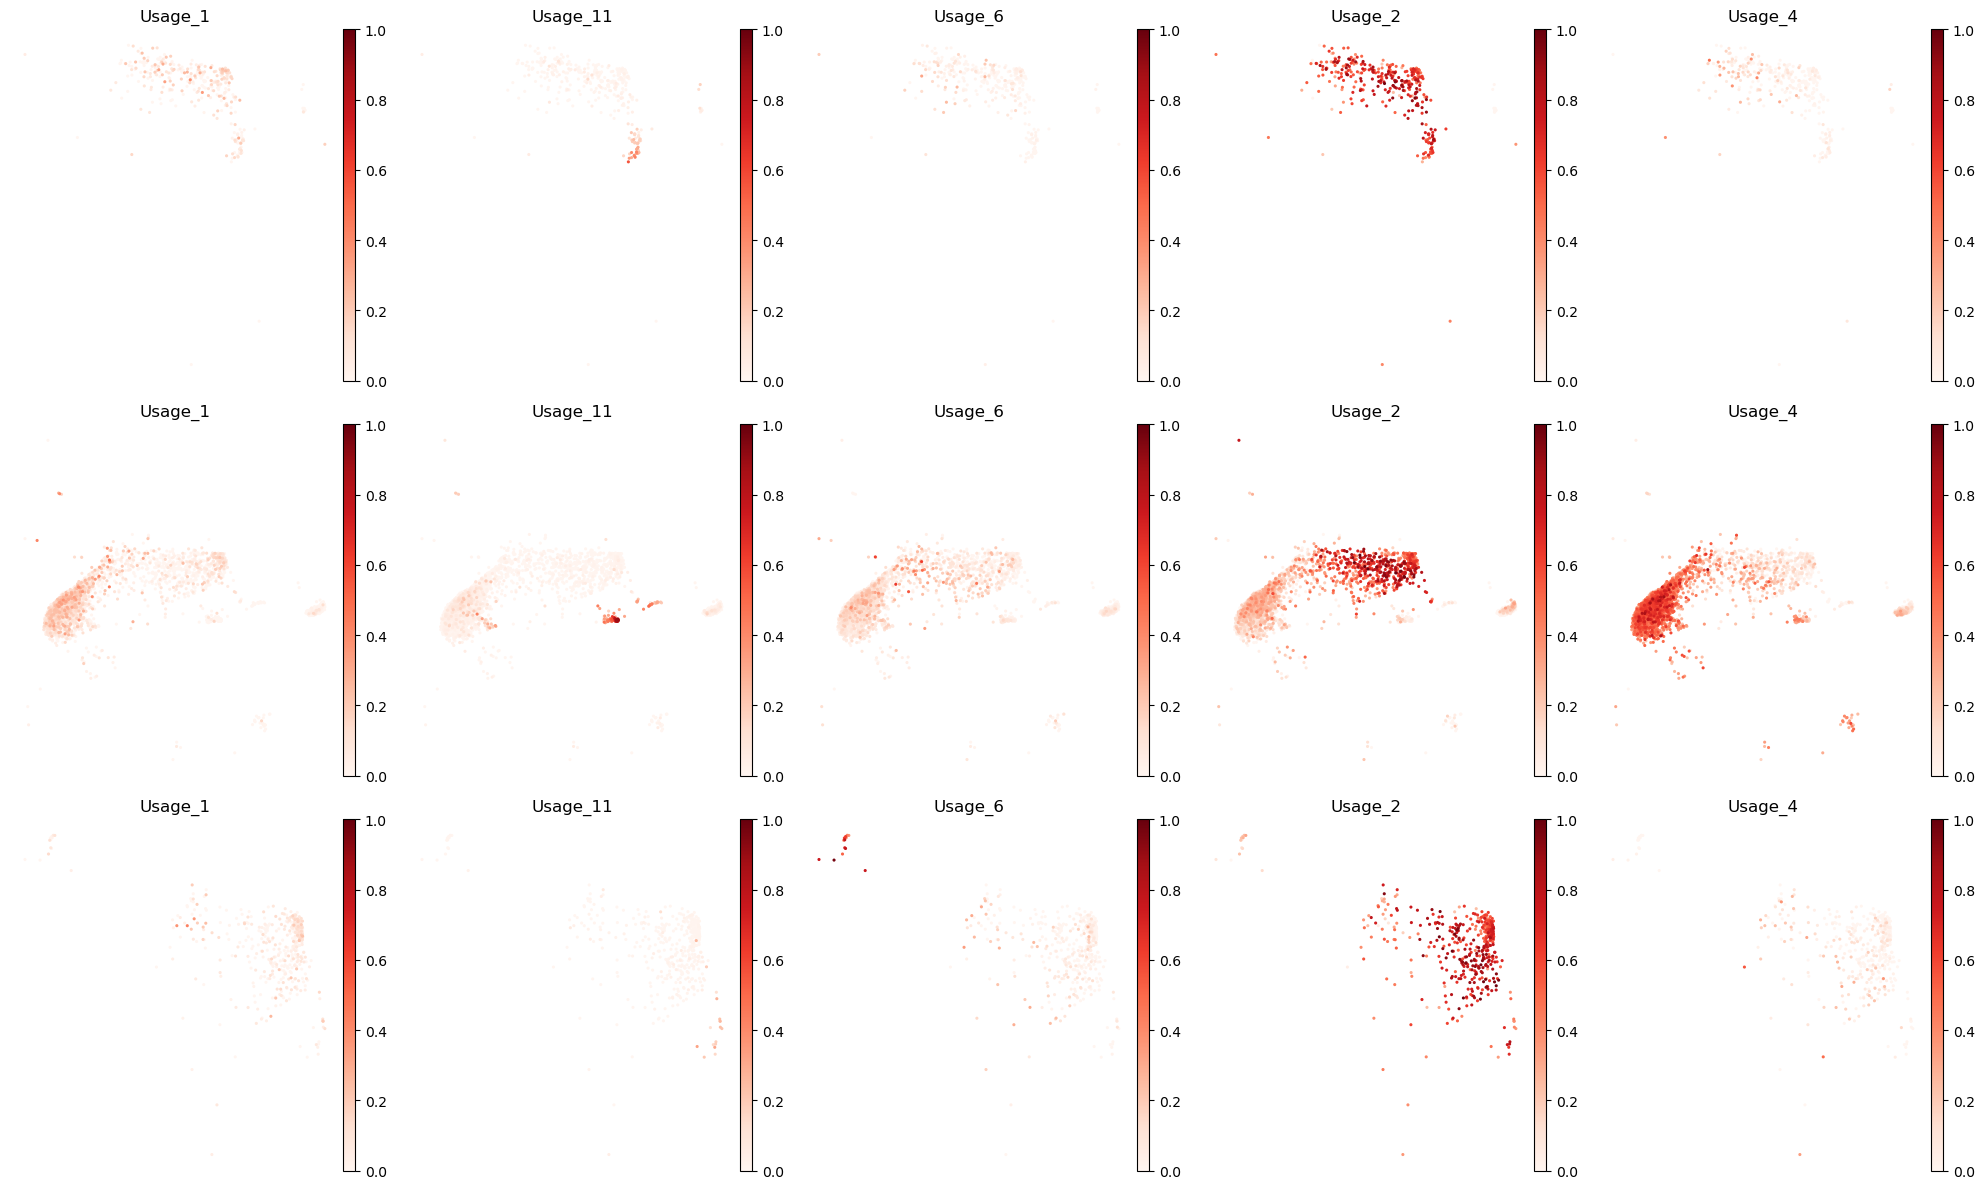

In [8]:
# Get all sample IDs with "post" or "refrac" in orig.ident
samples = [s for s in adata_orig.obs["orig.ident"].unique() 
           if ("post" in s)]

colors = ["Usage_1", "Usage_11", "Usage_6", "Usage_2", "Usage_4"]

# Build on big figure:
nrows = len(samples)
ncols = len(colors)
fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols, figsize=(4*ncols, 4*nrows),
    squeeze=False
)

# Loop over samples × colors
for i, sample in enumerate(samples):
    adata_sub = adata_orig[adata_orig.obs["orig.ident"] == sample, :]
    for j, col in enumerate(colors):
        sc.pl.embedding(
            adata_sub,
            basis="X_umap",size=20 ,
            color=col,
            frameon=False,
            color_map="Reds",
            ax=axes[i, j],    # draw into the subplot
            show=False,
            vmin=0, vmax=adata_orig.obs[colors].max().max()  # shared scaling
        )
        if i == 0:
            axes[i, j].set_title(col, fontsize=12)
        if j == 0:
            axes[i, j].set_ylabel(sample, fontsize=12)

# Make a shared colorbar
# Grab the first image from one subplot
im = axes[0, 0].collections[0]
#fig.colorbar(im, ax=axes, orientation="vertical", fraction=0.02, pad=0.02, label="Usage score")

plt.tight_layout()
plt.show()


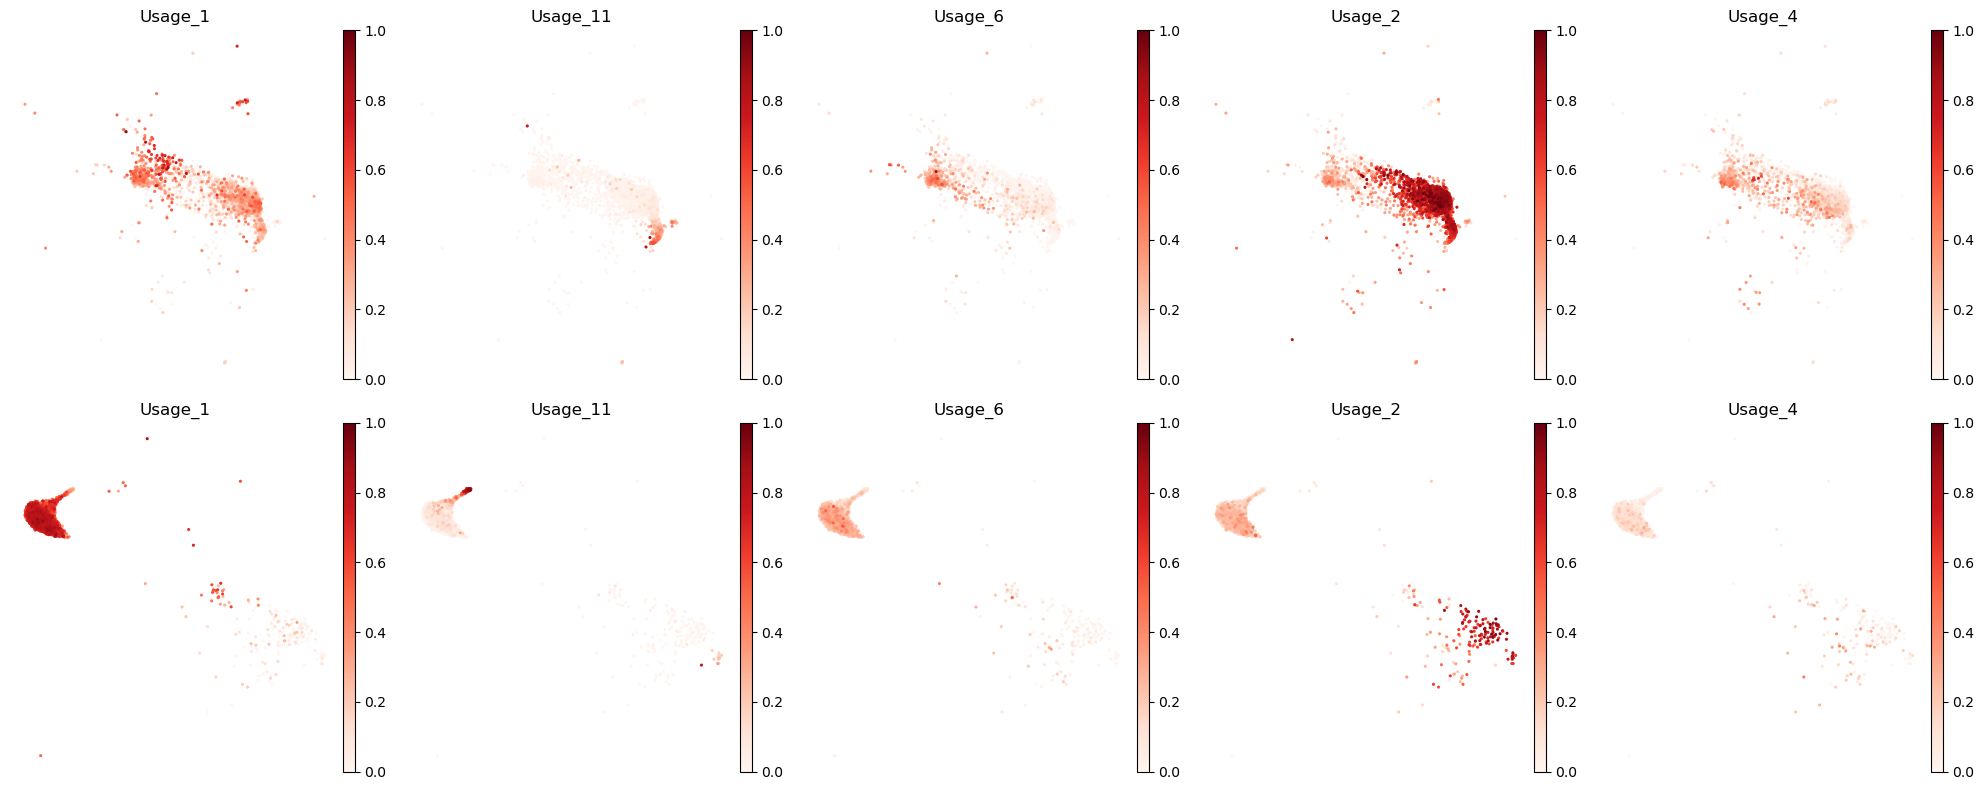

In [9]:
# Get all sample IDs with "post" or "refrac" in orig.ident
samples = [s for s in adata_orig.obs["orig.ident"].unique() 
           if  ("refrac" in s)]

colors = ["Usage_1", "Usage_11", "Usage_6", "Usage_2", "Usage_4"]

# Build on big figure:
nrows = len(samples)
ncols = len(colors)
fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols, figsize=(4*ncols, 4*nrows),
    squeeze=False
)

# Loop over samples × colors
for i, sample in enumerate(samples):
    adata_sub = adata_orig[adata_orig.obs["orig.ident"] == sample, :]
    for j, col in enumerate(colors):
        sc.pl.embedding(
            adata_sub,
            basis="X_umap",size=20 ,
            color=col,
            frameon=False,
            color_map="Reds",
            ax=axes[i, j],    # draw into the subplot
            show=False,
            vmin=0, vmax=adata_orig.obs[colors].max().max()  # shared scaling
        )
        if i == 0:
            axes[i, j].set_title(col, fontsize=12)
        if j == 0:
            axes[i, j].set_ylabel(sample, fontsize=12)

# Make a shared colorbar
# Grab the first image from one subplot
im = axes[0, 0].collections[0]
#fig.colorbar(im, ax=axes, orientation="vertical", fraction=0.02, pad=0.02, label="Usage score")

plt.tight_layout()
plt.show()


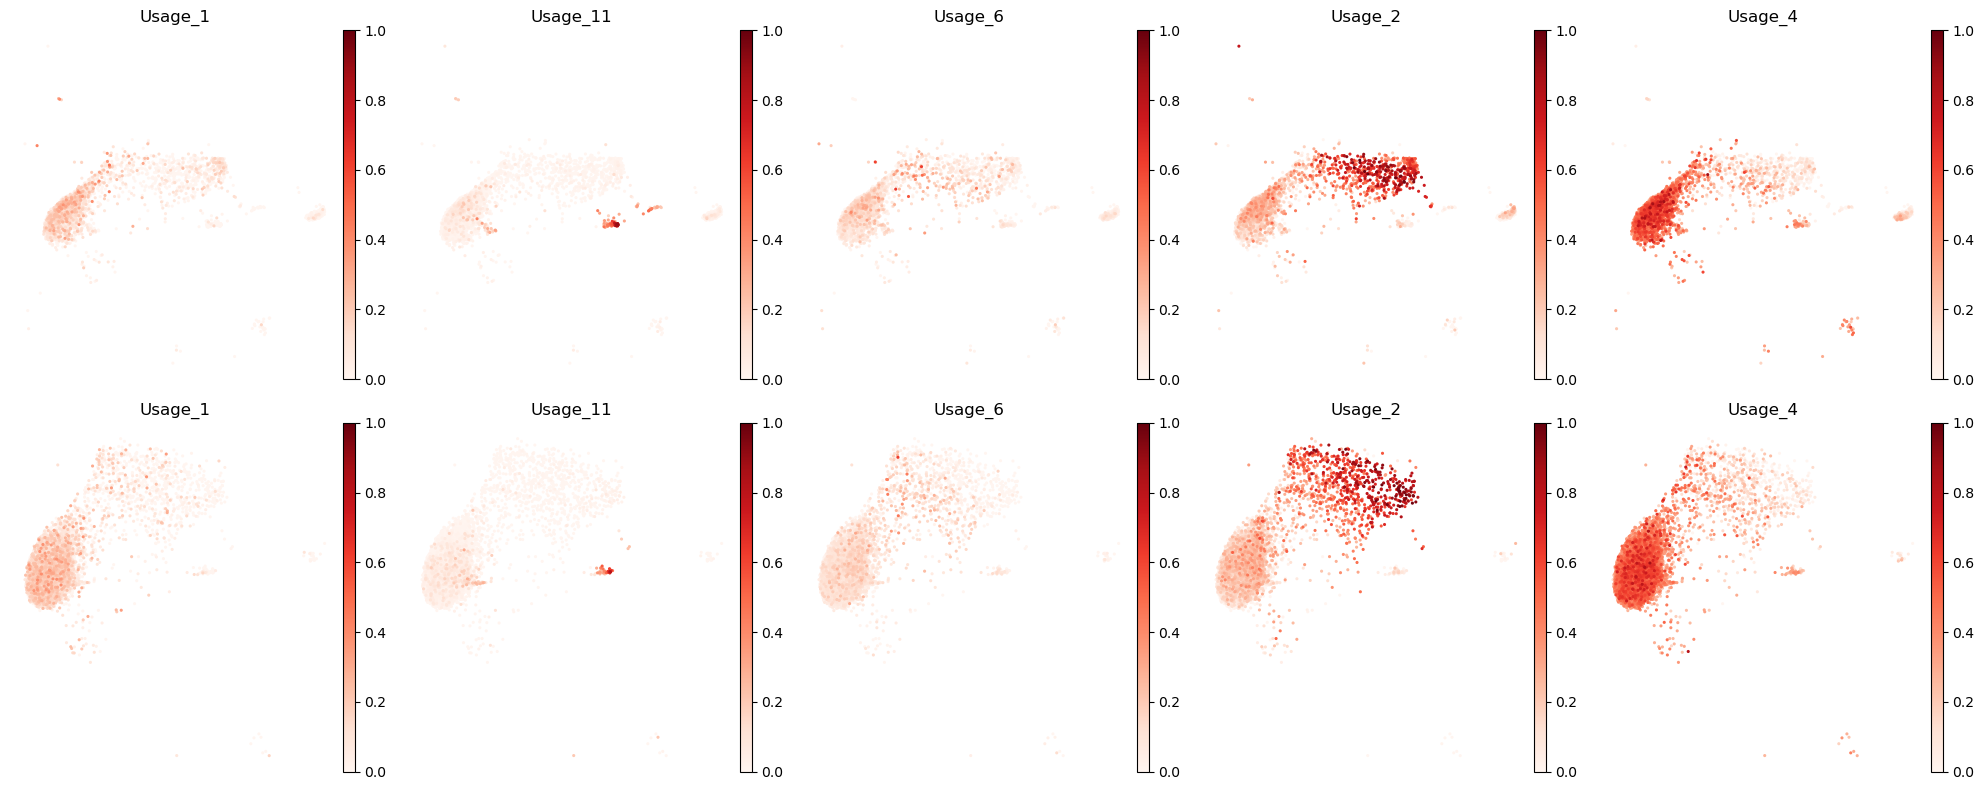

In [10]:
# Get all sample IDs with "post" or "refrac" in orig.ident
samples = [s for s in adata_orig.obs["orig.ident"].unique() 
           if ("ALl5" in s) ]

colors = ["Usage_1", "Usage_11", "Usage_6", "Usage_2", "Usage_4"]

# Build on big figure:
nrows = len(samples)
ncols = len(colors)
fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols, figsize=(4*ncols, 4*nrows),
    squeeze=False
)

# Loop over samples × colors
for i, sample in enumerate(samples):
    adata_sub = adata_orig[adata_orig.obs["orig.ident"] == sample, :]
    for j, col in enumerate(colors):
        sc.pl.embedding(
            adata_sub,
            basis="X_umap",size=20 ,
            color=col,
            frameon=False,
            color_map="Reds",
            ax=axes[i, j],    # draw into the subplot
            show=False,
            vmin=0, vmax=adata_orig.obs[colors].max().max()  # shared scaling
        )
        if i == 0:
            axes[i, j].set_title(col, fontsize=12)
        if j == 0:
            axes[i, j].set_ylabel(sample, fontsize=12)

# Make a shared colorbar
# Grab the first image from one subplot
im = axes[0, 0].collections[0]
#fig.colorbar(im, ax=axes, orientation="vertical", fraction=0.02, pad=0.02, label="Usage score")

plt.tight_layout()
plt.show()


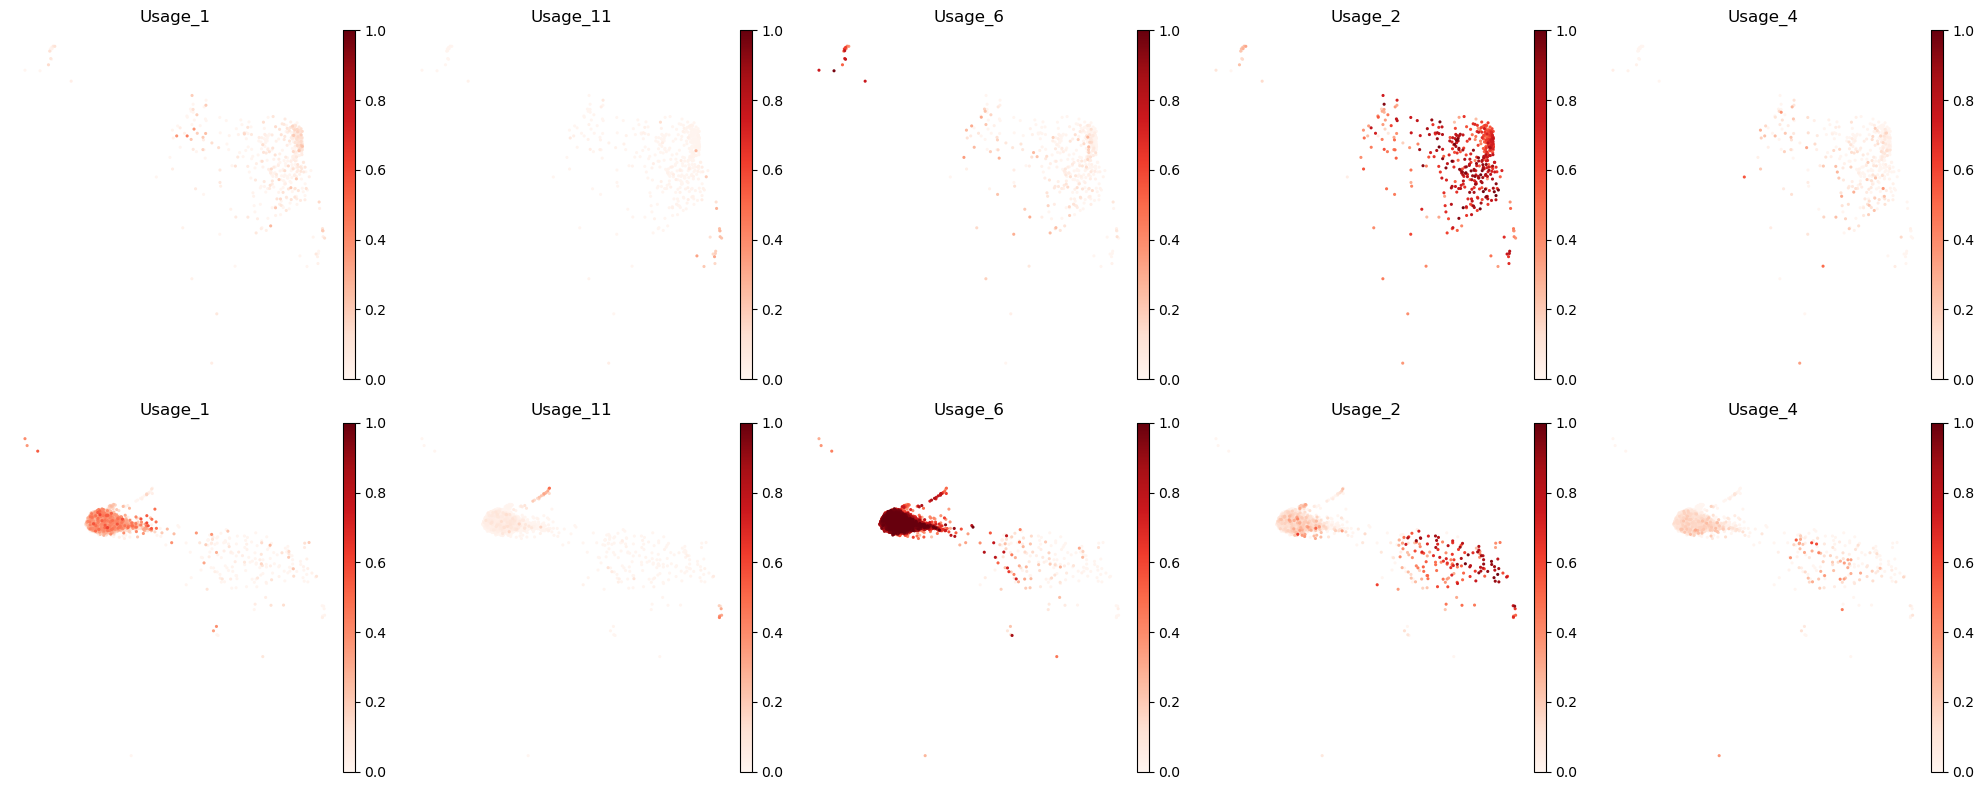

In [11]:
# Get all sample IDs with "post" or "refrac" in orig.ident
samples = [s for s in adata_orig.obs["orig.ident"].unique() 
           if ("ALk3" in s)]

colors = ["Usage_1", "Usage_11", "Usage_6", "Usage_2", "Usage_4"]

# Build on big figure:
nrows = len(samples)
ncols = len(colors)
fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols, figsize=(4*ncols, 4*nrows),
    squeeze=False
)

# Loop over samples × colors
for i, sample in enumerate(samples):
    adata_sub = adata_orig[adata_orig.obs["orig.ident"] == sample, :]
    for j, col in enumerate(colors):
        sc.pl.embedding(
            adata_sub,
            basis="X_umap",size=20 ,
            color=col,
            frameon=False,
            color_map="Reds",
            ax=axes[i, j],    # draw into the subplot
            show=False,
            vmin=0, vmax=adata_orig.obs[colors].max().max()  # shared scaling
        )
        if i == 0:
            axes[i, j].set_title(col, fontsize=12)
        if j == 0:
            axes[i, j].set_ylabel(sample, fontsize=12)

# Make a shared colorbar
# Grab the first image from one subplot
im = axes[0, 0].collections[0]
#fig.colorbar(im, ax=axes, orientation="vertical", fraction=0.02, pad=0.02, label="Usage score")

plt.tight_layout()
plt.show()


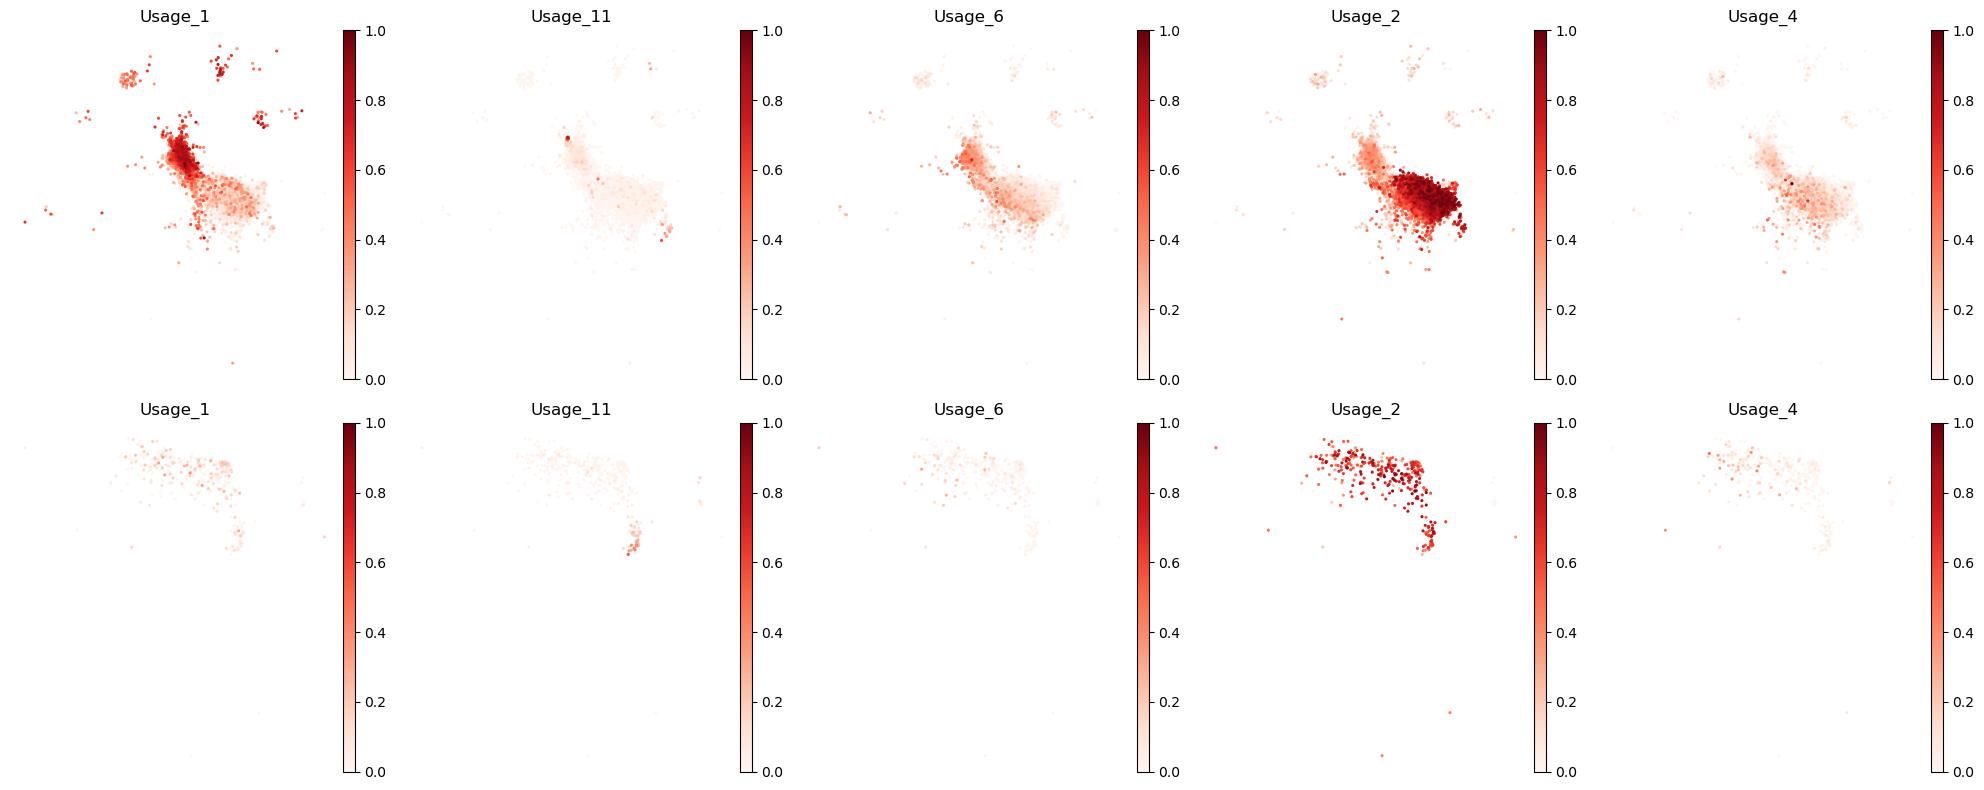

In [12]:
# Get all sample IDs with "post" or "refrac" in orig.ident
samples = [s for s in adata_orig.obs["orig.ident"].unique() 
           if  ("ALl9" in s)]

colors = ["Usage_1", "Usage_11", "Usage_6", "Usage_2", "Usage_4"]

# Build on big figure:
nrows = len(samples)
ncols = len(colors)
fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols, figsize=(4*ncols, 4*nrows),
    squeeze=False
)

# Loop over samples × colors
for i, sample in enumerate(samples):
    adata_sub = adata_orig[adata_orig.obs["orig.ident"] == sample, :]
    for j, col in enumerate(colors):
        sc.pl.embedding(
            adata_sub,
            basis="X_umap",size=20 ,
            color=col,
            frameon=False,
            color_map="Reds",
            ax=axes[i, j],    # draw into the subplot
            show=False,
            vmin=0, vmax=adata_orig.obs[colors].max().max()  # shared scaling
        )
        if i == 0:
            axes[i, j].set_title(col, fontsize=12)
        if j == 0:
            axes[i, j].set_ylabel(sample, fontsize=12)

# Make a shared colorbar
# Grab the first image from one subplot
im = axes[0, 0].collections[0]
#fig.colorbar(im, ax=axes, orientation="vertical", fraction=0.02, pad=0.02, label="Usage score")

plt.tight_layout()
plt.show()
